In [1]:
print("STUDENT ANALYTICS SYSTEM")

STUDENT ANALYTICS SYSTEM


In [2]:
!pip install pyspark pyarrow

In [3]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from pyspark.sql import SparkSession

In [4]:
from google.colab import files

uploaded = files.upload()

Saving student_performance.csv to student_performance (1).csv


In [5]:
df = pd.read_csv("student_performance.csv")

df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [6]:
print(df.shape)

print(df.isnull().sum())

df = df.drop_duplicates()

print("Duplicates Removed")

df.info()

(30, 13)
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64
Duplicates Removed
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     in

In [7]:
raw_df = df.copy()

print("Data Extracted")

Data Extracted


In [8]:
df.columns = df.columns.str.strip()

print("Transformation Completed")

Transformation Completed


In [9]:
clean_df = df.copy()

print("Data Loaded")

Data Loaded


In [10]:
conn = sqlite3.connect("student.db")

clean_df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created")

Database Created


In [11]:
pd.read_sql(
'''
SELECT COUNT(*) FROM students
''',
conn
)

,COUNT(*)
0,30


In [12]:
pd.read_sql(
'''
SELECT AVG(programming_score)
FROM students
''',
conn
)

,AVG(programming_score)
0,67.6


In [13]:
pd.read_sql(
'''
SELECT department,
AVG(programming_score)
FROM students
GROUP BY department
''',
conn
)

,department,AVG(programming_score)
0,Civil,40.600000
1,Computer Science,89.230769
2,Electronics,61.500000
3,Mechanical,49.333333


In [14]:
pd.read_sql(
'''
SELECT *
FROM students
ORDER BY programming_score DESC
LIMIT 5
''',
conn
)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023
1,1022,Tanvi Mehta,19,Female,Computer Science,2,93,90,88,96,97,Surat,2023
2,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
3,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023
4,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023


In [15]:
pd.read_sql(
'''
SELECT department,
COUNT(*)
FROM students
GROUP BY department
''',
conn
)

,department,COUNT(*)
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


In [17]:
spark = SparkSession.builder \
    .appName("StudentAnalytics") \
    .getOrCreate()

In [18]:
bronze_df = spark.read.csv(
    "student_performance.csv",
    header=True,
    inferSchema=True
)

bronze_df.show(5)

+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|          2023

In [19]:
silver_df = bronze_df.dropDuplicates()

silver_df.show(5)

+----------+--------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+
|student_id|          name|age|gender| department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|              city|admission_year|
+----------+--------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+
|      1028| Sunita Pillai| 19|Female|      Civil|       2|        60|           65|           68|               39|                   73|Thiruvananthapuram|          2023|
|      1019|Deepak Chauhan| 20|  Male| Mechanical|       2|        68|           73|           62|               49|                   77|          Dehradun|          2023|
|      1006|   Meera Joshi| 20|Female|Electronics|       2|        58|           66|           70|               52|                   

In [20]:
gold_df = silver_df.groupBy(
    "department"
).avg(
    "programming_score"
)

gold_df.show()

+----------------+----------------------+
|      department|avg(programming_score)|
+----------------+----------------------+
|      Mechanical|    49.333333333333336|
|     Electronics|                  61.5|
|           Civil|                  40.6|
|Computer Science|     89.23076923076923|
+----------------+----------------------+



In [21]:
silver_df.write.mode("overwrite").parquet(
    "student_parquet"
)

In [22]:
import os

csv_size = os.path.getsize(
    "student_performance.csv"
)

print(
    "CSV Size:",
    csv_size
)

print(
    "Parquet Created Successfully"
)

CSV Size: 2243
Parquet Created Successfully


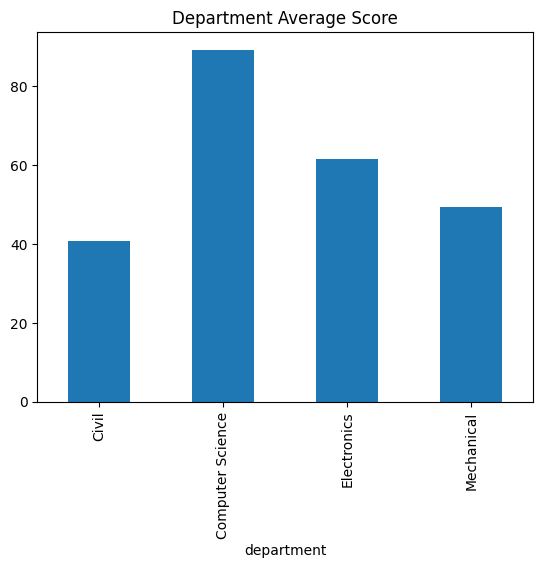

In [23]:
df.groupby(
    'department'
)['programming_score'].mean().plot(
    kind='bar'
)

plt.title(
    "Department Average Score"
)

plt.show()

In [25]:
print(df.columns)

Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')


In [26]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


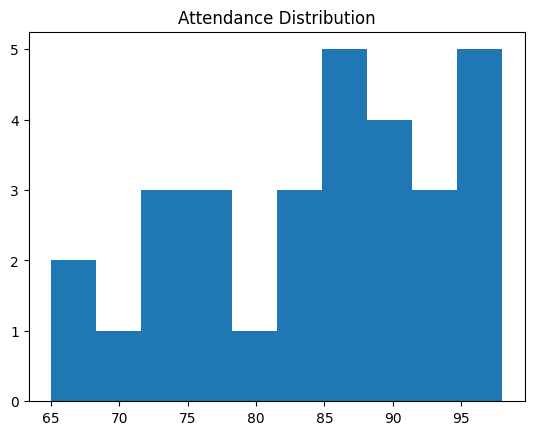

In [27]:
plt.hist(df['attendance_percentage'])

plt.title("Attendance Distribution")

plt.show()

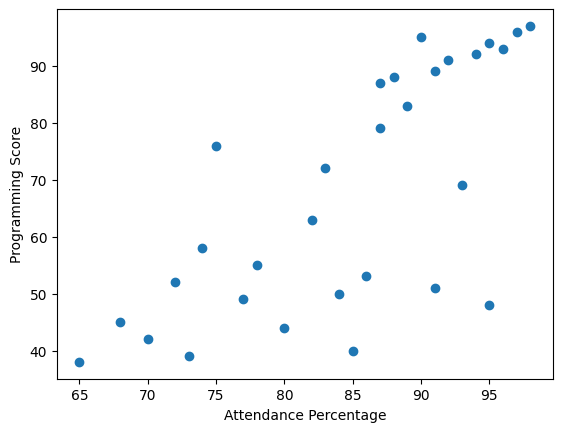

In [28]:
plt.scatter(
    df['attendance_percentage'],
    df['programming_score']
)

plt.xlabel("Attendance Percentage")
plt.ylabel("Programming Score")

plt.show()

In [29]:
X = df[['attendance_percentage']]

y = df['programming_score']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model = RandomForestRegressor()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 10.230833333333331


In [32]:
prediction = model.predict([[85]])

print("Predicted Programming Score:", prediction[0])

Predicted Programming Score: 47.41


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [33]:
print("========== STUDENT ANALYTICS REPORT ==========")

print("Dataset Loaded Successfully")
print("Data Cleaning Completed")
print("ETL Pipeline Completed")
print("SQLite Database Created")
print("5 SQL Queries Executed")
print("3 Visualizations Generated")
print("Random Forest Model Trained")
print("Prediction Completed")
print("GitHub Ready")

print("PROJECT COMPLETED SUCCESSFULLY")

========== STUDENT ANALYTICS REPORT ==========
Dataset Loaded Successfully
Data Cleaning Completed
ETL Pipeline Completed
SQLite Database Created
5 SQL Queries Executed
3 Visualizations Generated
Random Forest Model Trained
Prediction Completed
GitHub Ready
PROJECT COMPLETED SUCCESSFULLY
